# Exploratory Data Analysis

## Research Question 1
AI Replacement and Burnout

## Research Question 2
Education, AI Engagement and Fear of AI Replacement

## Research Question 3
Productivity-Burnout Tradeoff

## Research Question 4
Differences Across Job Roles and Industries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/ai_worker_burnout_cleaned.csv"
)

In [3]:
df.groupby("fear_of_ai_replacement")["burnout_score"].mean()



fear_of_ai_replacement
High      49.391061
Low       50.397706
Medium    50.155089
Name: burnout_score, dtype: float64

In [4]:
df.groupby("attrition_risk")["burnout_score"].mean()

attrition_risk
High      60.80000
Low       44.03453
Medium    55.04631
Name: burnout_score, dtype: float64

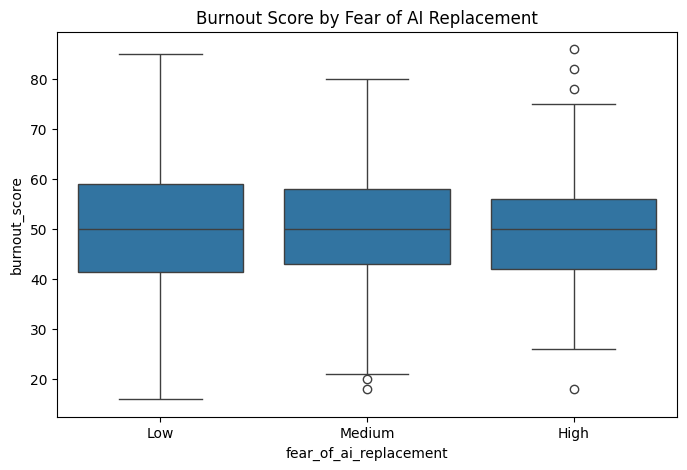

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="fear_of_ai_replacement",
    y="burnout_score"
)

plt.title("Burnout Score by Fear of AI Replacement")

plt.show()

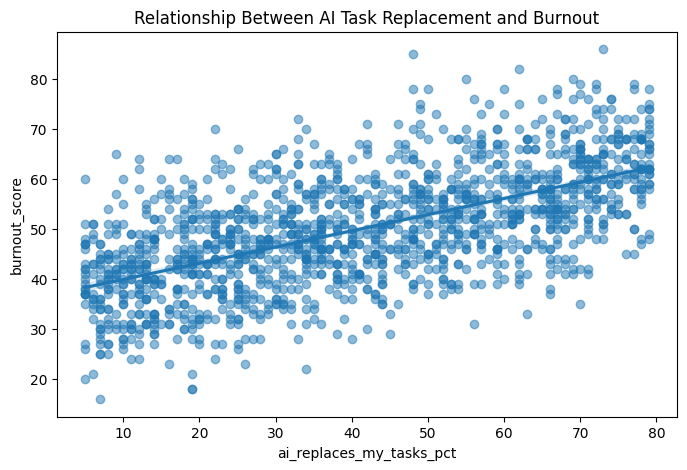

In [6]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="ai_replaces_my_tasks_pct",
    y="burnout_score",
    scatter_kws={"alpha":0.5}
)

plt.title("Relationship Between AI Task Replacement and Burnout")

plt.show()

### Initial Observation

A clear positive relationship can be observed between perceived AI task replacement and burnout score.

Employees reporting higher percentages of AI-replaced tasks tend to show higher burnout levels. However, the dataset does not allow causal conclusions and the observed relationship should be interpreted as an association rather than evidence of causation.

<Axes: xlabel='hours_with_ai_assistance_daily', ylabel='productivity_score'>

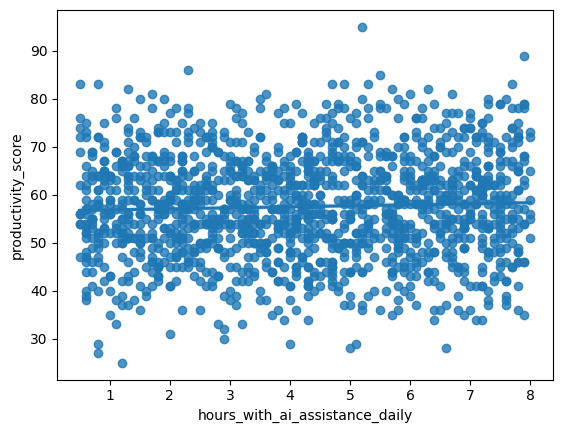

In [9]:
sns.regplot(
    data=df,
    x="hours_with_ai_assistance_daily",
    y="productivity_score"
)

<Axes: xlabel='hours_with_ai_assistance_daily', ylabel='burnout_score'>

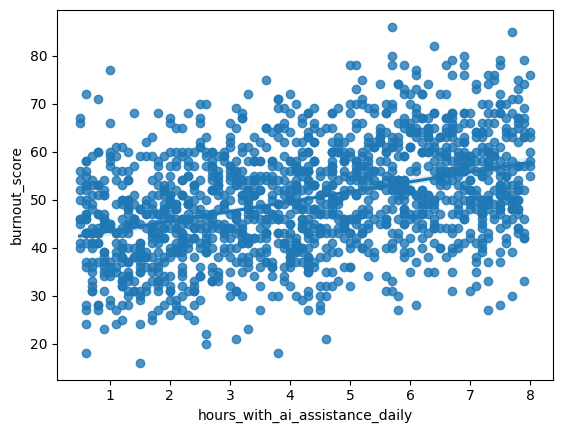

In [8]:
sns.regplot(
    data=df,
    x="hours_with_ai_assistance_daily",
    y="burnout_score"
)

In [9]:
df.groupby(
    "ai_adoption_stage"
)["burnout_score"].mean()

ai_adoption_stage
AI-First         50.492000
Experimenting    49.667598
Integrating      50.166667
Optimizing       50.000000
Name: burnout_score, dtype: float64

<Axes: xlabel='ai_adoption_stage', ylabel='burnout_score'>

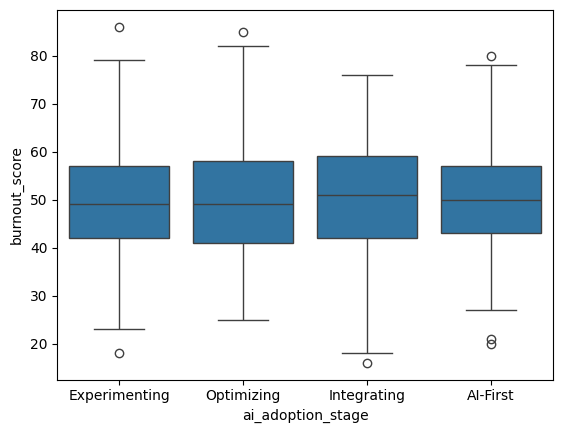

In [10]:
sns.boxplot(
    data=df,
    x="ai_adoption_stage",
    y="burnout_score"
)

<Axes: xlabel='education_level', ylabel='ai_replaces_my_tasks_pct'>

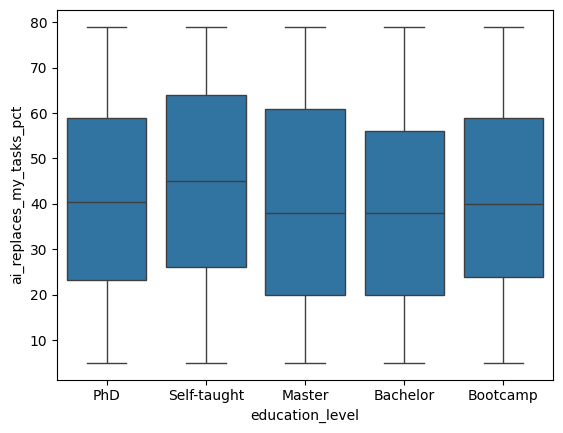

In [11]:
sns.boxplot(
    data=df,
    x="education_level",
    y="ai_replaces_my_tasks_pct"
)

<Axes: xlabel='attrition_risk', ylabel='burnout_score'>

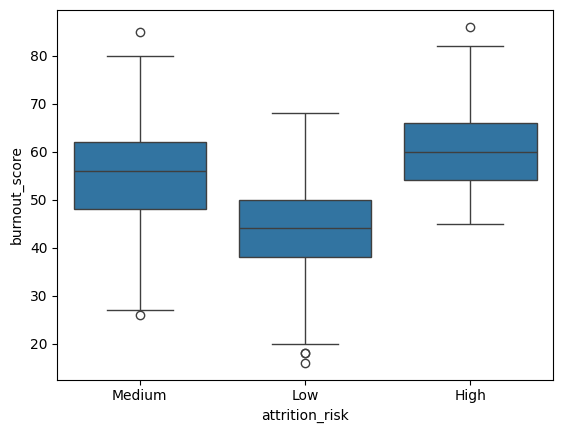

In [12]:
sns.boxplot(
    data=df,
    x="attrition_risk",
    y="burnout_score"
)

In [13]:
df.groupby("job_role")["burnout_score"].mean().sort_values()

job_role
Prompt Engineer      47.657143
AI Researcher        48.748148
Product Manager      49.121951
Frontend Engineer    49.310345
AI Ethics Officer    49.712121
Cloud Architect      50.376923
Data Scientist       50.548148
ML Engineer          50.697248
Backend Engineer     50.921260
Data Analyst         50.926230
DevOps Engineer      50.931034
Software Engineer    51.266667
Name: burnout_score, dtype: float64

In [14]:
df.groupby("industry")["burnout_score"].mean().sort_values()

industry
Automotive       48.720779
Cybersecurity    49.765625
Consulting       49.792208
Fintech          49.833333
Media            49.918367
Healthtech       50.073826
EdTech           50.123529
E-commerce       50.529032
Gaming           50.532164
SaaS             51.305970
Name: burnout_score, dtype: float64

In [15]:
df.groupby("remote_work_type")["burnout_score"].mean()

remote_work_type
Fully Remote    50.217993
Hybrid          49.627713
On-site         50.566563
Name: burnout_score, dtype: float64

In [16]:
df.groupby(
    pd.cut(
        df["hours_with_ai_assistance_daily"],
        bins=[0,2,4,6,8]
    )
)["burnout_score"].mean()

hours_with_ai_assistance_daily
(0, 2]    43.729642
(2, 4]    47.721805
(4, 6]    51.890511
(6, 8]    55.595300
Name: burnout_score, dtype: float64

In [17]:
corr = df[
    ["hours_with_ai_assistance_daily",
     "burnout_score",
     "productivity_score"]
].corr()
corr


,hours_with_ai_assistance_daily,burnout_score,productivity_score
hours_with_ai_assistance_daily,1.000000,0.385597,0.043123
burnout_score,0.385597,1.000000,-0.005322
productivity_score,0.043123,-0.005322,1.000000


In [18]:
df.groupby(
    pd.cut(
        df["hours_with_ai_assistance_daily"],
        bins=[0,2,4,6,8]
    )
)[
    ["productivity_score",
     "job_satisfaction_1_5"]
].mean()

,productivity_score,job_satisfaction_1_5
hours_with_ai_assistance_daily,,
"(0, 2]",57.254072,3.580456
"(2, 4]",56.889724,3.412782
"(4, 6]",57.574209,3.262287
"(6, 8]",58.422977,3.134204


In [19]:
df.groupby("ai_tools_used_per_day")[
    "productivity_score"
].mean()

ai_tools_used_per_day
1    52.782178
2    53.545000
3    54.876777
4    58.213043
5    59.964758
6    60.657407
7    61.971963
Name: productivity_score, dtype: float64

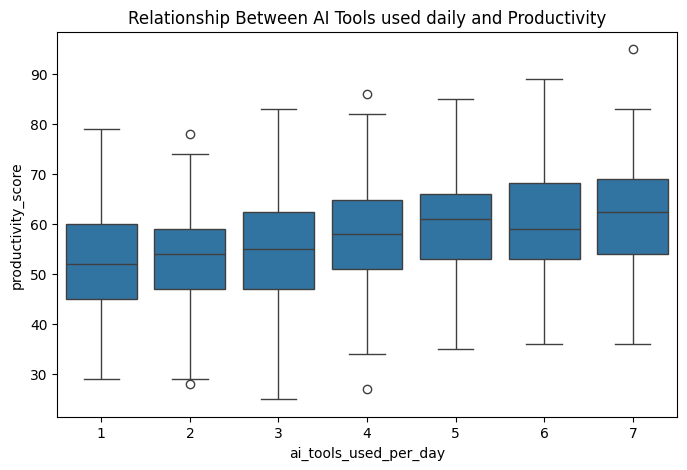

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="ai_tools_used_per_day",
    y="productivity_score"
)

plt.title("Relationship Between AI Tools used daily and Productivity")

plt.show()

In [38]:
df.groupby(
    pd.cut(
        df["hours_with_ai_assistance_daily"],
        bins=[0,2,4,6,8]
    )
)[
    [
        "productivity_score",
        "burnout_score"
    ]
].mean()



,productivity_score,burnout_score
hours_with_ai_assistance_daily,,
"(0, 2]",57.254072,43.729642
"(2, 4]",56.889724,47.721805
"(4, 6]",57.574209,51.890511
"(6, 8]",58.422977,55.595300


In [24]:
df.groupby(
    pd.cut(
        df["hours_with_ai_assistance_daily"],
        bins=[0,2,4,6,8]
    )
)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

,productivity_score,burnout_score,job_satisfaction_1_5
hours_with_ai_assistance_daily,,,
"(0, 2]",57.254072,43.729642,3.580456
"(2, 4]",56.889724,47.721805,3.412782
"(4, 6]",57.574209,51.890511,3.262287
"(6, 8]",58.422977,55.595300,3.134204


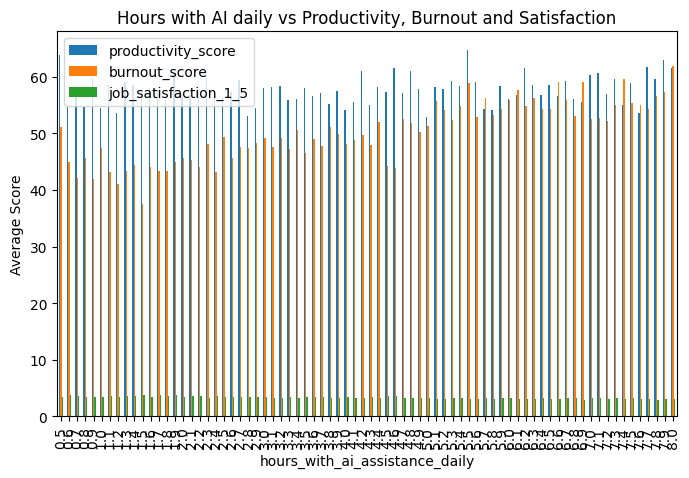

In [39]:
summary_hours = df.groupby(
    "hours_with_ai_assistance_daily"
)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

summary_hours.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Hours with AI daily vs Productivity, Burnout and Satisfaction")
plt.ylabel("Average Score")
plt.show()

<Axes: xlabel='hours_with_ai_assistance_daily', ylabel='burnout_score'>

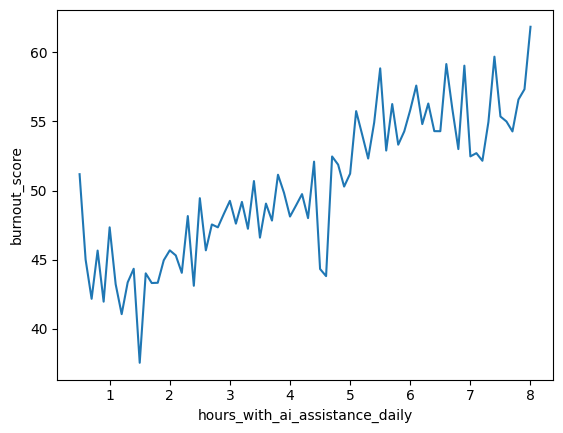

In [41]:
sns.lineplot(
    data=df,
    x="hours_with_ai_assistance_daily",
    y="burnout_score",
    errorbar=None
)

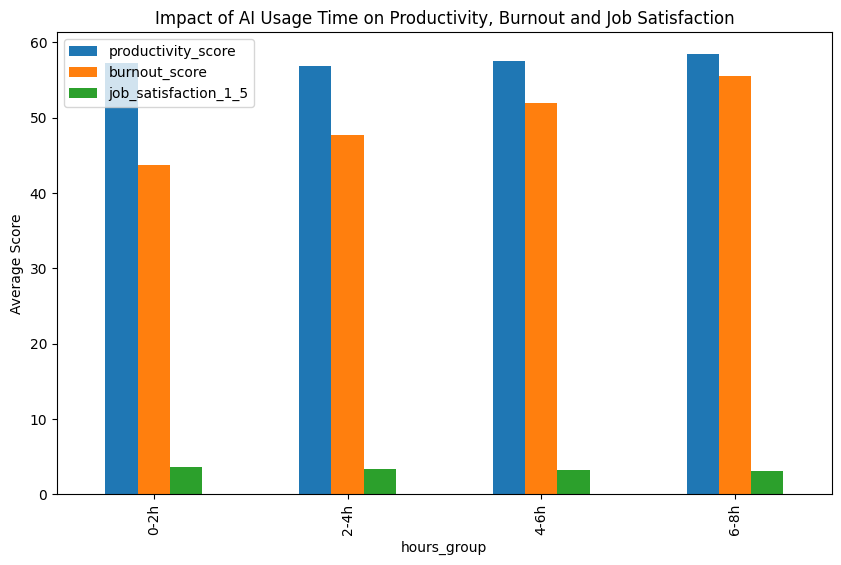

In [43]:
df["hours_group"] = pd.cut(
    df["hours_with_ai_assistance_daily"],
    bins=[0,2,4,6,8],
    labels=["0-2h","2-4h","4-6h","6-8h"]
)

summary_hours = df.groupby("hours_group")[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

summary_hours


summary_hours.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Impact of AI Usage Time on Productivity, Burnout and Job Satisfaction")
plt.ylabel("Average Score")
plt.show()

In [45]:
summary_scaled = (
    summary_hours - summary_hours.min()
) / (
    summary_hours.max() - summary_hours.min()
)

summary_scaled

,productivity_score,burnout_score,job_satisfaction_1_5
hours_group,,,
0-2h,0.237630,0.000000,1.000000
2-4h,0.000000,0.336447,0.624262
4-6h,0.446427,0.687772,0.287020
6-8h,1.000000,1.000000,0.000000


In [47]:
summary_scaled = summary_scaled.rename(
    columns={
        "productivity_score": "Productivity",
        "burnout_score": "Burnout risk",
        "job_satisfaction_1_5": "Job satisfaction"
    }
)

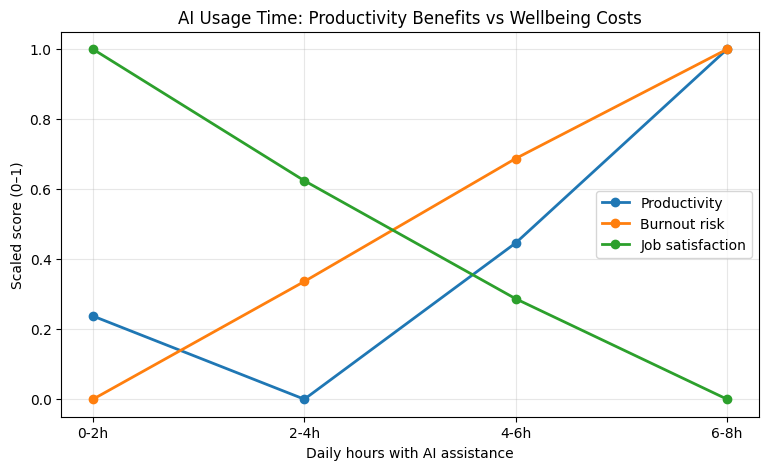

In [48]:
plt.figure(figsize=(9, 5))

for col in summary_scaled.columns:
    plt.plot(
        summary_scaled.index,
        summary_scaled[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("AI Usage Time: Productivity Benefits vs Wellbeing Costs")
plt.xlabel("Daily hours with AI assistance")
plt.ylabel("Scaled score (0–1)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

To compare variables measured on different scales, productivity, burnout and job satisfaction were normalized to a 0–1 range. This allows the trends to be compared visually without implying that the original scores use the same measurement scale.

To compare variables measured on different scales, productivity, burnout and job satisfaction were normalized to a 0–1 range. This allows the trends to be compared visually without implying that the original scores use the same measurement scale.

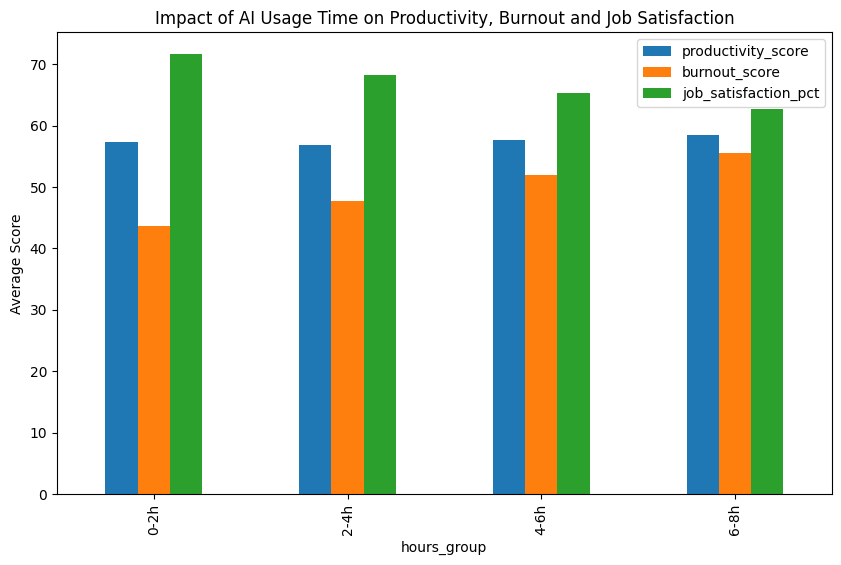

In [65]:
summary_hours_display = summary_hours.copy()

summary_hours_display["job_satisfaction_pct"] = (
    summary_hours_display["job_satisfaction_1_5"] / 5 * 100
)
summary_hours_display[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_pct"
    ]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Impact of AI Usage Time on Productivity, Burnout and Job Satisfaction")
plt.ylabel("Average Score")
plt.show()

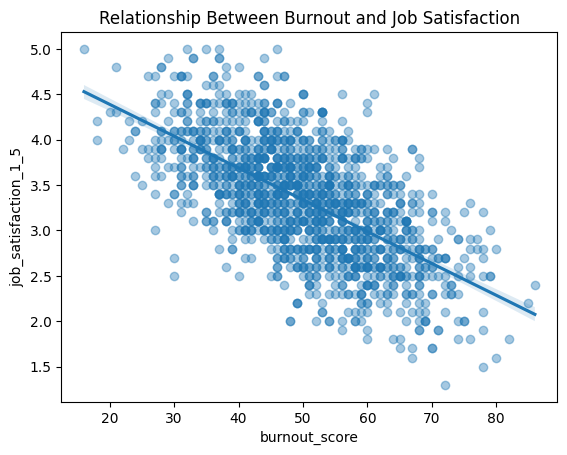

In [25]:
sns.regplot(
    data=df,
    x="burnout_score",
    y="job_satisfaction_1_5",
    scatter_kws={"alpha":0.4}
)

plt.title(
    "Relationship Between Burnout and Job Satisfaction"
)

plt.show()

In [33]:
df.groupby(
    pd.cut(
        df["ai_tools_used_per_day"],
        bins=[0,2,4,7],
    labels=["Low","Medium","High"]
    )
)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

,productivity_score,burnout_score,job_satisfaction_1_5
ai_tools_used_per_day,,,
Low,53.161692,50.390547,3.280100
Medium,56.616780,49.791383,3.326077
High,60.846271,50.031963,3.373973


In [34]:
df.groupby(
    "ai_tools_used_per_day"
)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

,productivity_score,burnout_score,job_satisfaction_1_5
ai_tools_used_per_day,,,
1,52.782178,49.886139,3.308416
2,53.545000,50.900000,3.251500
3,54.876777,50.488152,3.310427
4,58.213043,49.152174,3.340435
5,59.964758,49.136564,3.393392
6,60.657407,50.782407,3.364352
7,61.971963,50.224299,3.363084


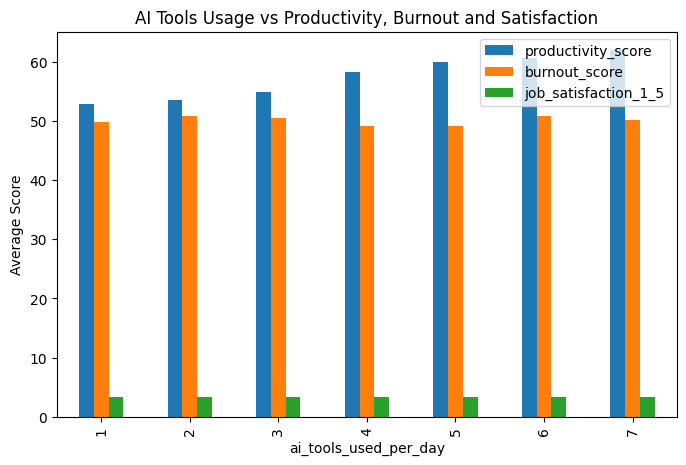

In [36]:
summary_tools = df.groupby(
    "ai_tools_used_per_day"
)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

summary_tools.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("AI Tools Usage vs Productivity, Burnout and Satisfaction")
plt.ylabel("Average Score")
plt.show()

In [50]:
summary_tools_scaled = (
    summary_tools - summary_tools.min()
) / (
    summary_tools.max() - summary_tools.min()
)

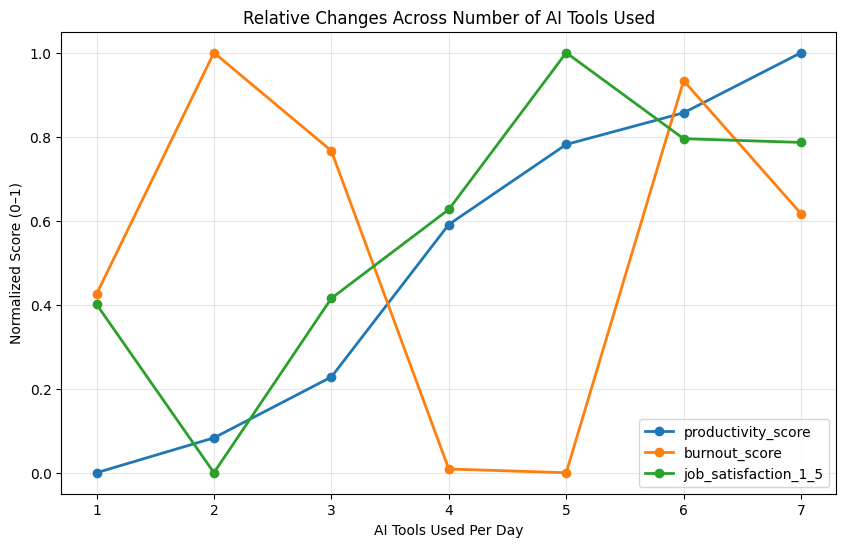

In [51]:
plt.figure(figsize=(10,6))

for col in summary_tools_scaled.columns:
    plt.plot(
        summary_tools_scaled.index,
        summary_tools_scaled[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title(
    "Relative Changes Across Number of AI Tools Used"
)

plt.xlabel("AI Tools Used Per Day")
plt.ylabel("Normalized Score (0–1)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [52]:
summary_tools_display = summary_tools.copy()

summary_tools_display["job_satisfaction_pct"] = (
    summary_tools_display["job_satisfaction_1_5"] / 5 * 100
)

<Axes: xlabel='ai_tools_used_per_day'>

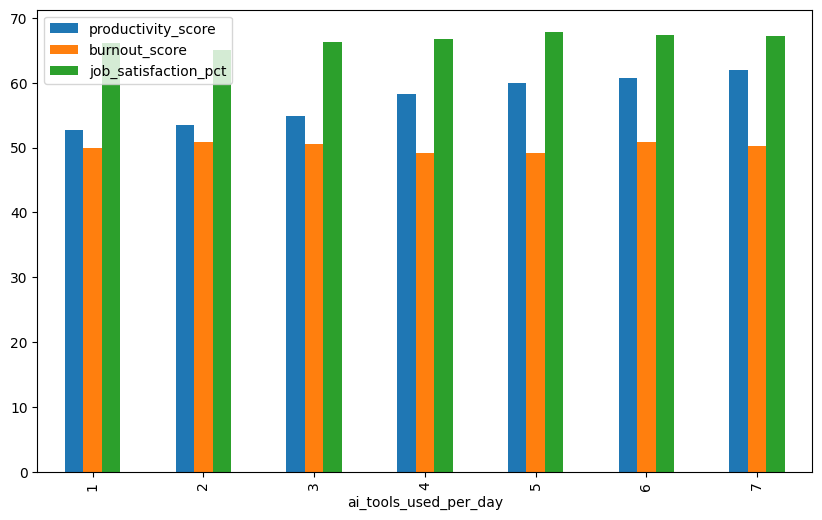

In [53]:
summary_tools_display[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_pct"
    ]
].plot(
    kind="bar",
    figsize=(10,6)
)

Productivity and burnout were already measured on a 0–100 scale. Job satisfaction was converted from a 1–5 scale into a percentage of the maximum possible score to allow visual comparison.

Text(0.5, 1.0, 'Correlation Matrix')

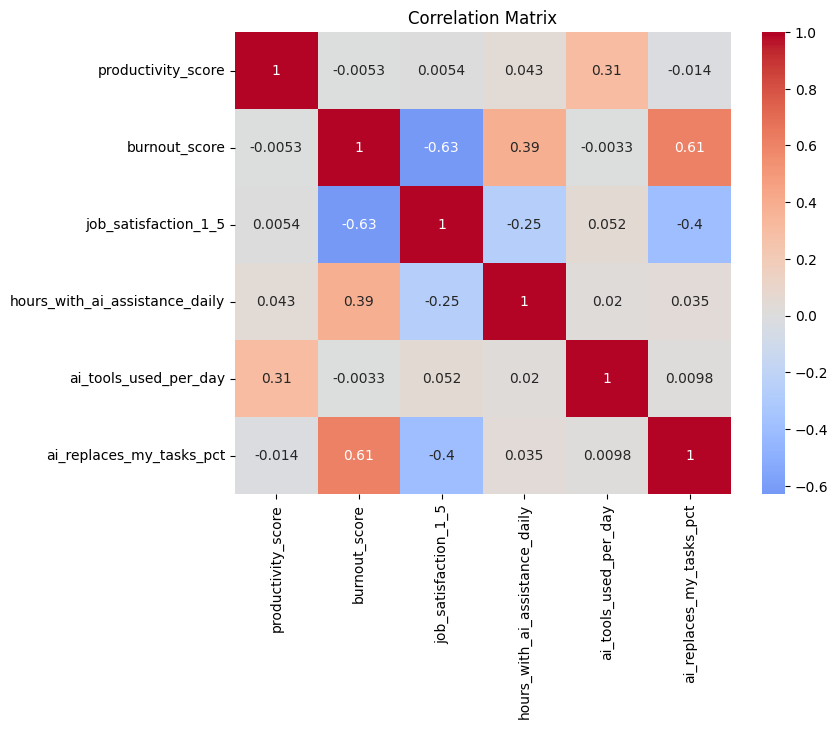

In [49]:
corr = df[
[
    "productivity_score",
    "burnout_score",
    "job_satisfaction_1_5",
    "hours_with_ai_assistance_daily",
    "ai_tools_used_per_day",
    "ai_replaces_my_tasks_pct"
]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")

In [54]:
# Create grouped AI usage variables

df["hours_group"] = pd.cut(
    df["hours_with_ai_assistance_daily"],
    bins=[0, 2, 5, 8],
    labels=["Low hours", "Medium hours", "High hours"],
    include_lowest=True
)

df["tools_group"] = pd.cut(
    df["ai_tools_used_per_day"],
    bins=[0, 2, 5, 7],
    labels=["Few tools", "Moderate tools", "Many tools"],
    include_lowest=True
)

# Calculate mean outcomes for each AI usage profile

profile_summary = (
    df.groupby(["hours_group", "tools_group"])[
        [
            "productivity_score",
            "burnout_score",
            "job_satisfaction_1_5"
        ]
    ]
    .mean()
    .round(2)
)

profile_summary

productivity_score  burnout_score  \
hours_group  tools_group                                         
Low hours    Few tools                    51.69          45.55   
             Moderate tools               58.04          42.38   
             Many tools                   61.31          44.04   
Medium hours Few tools                    53.87          48.58   
             Moderate tools               56.94          47.95   
             Many tools                   60.37          48.70   
High hours   Few tools                    53.21          54.92   
             Moderate tools               58.51          55.18   
             Many tools                   62.29          55.83   

                             job_satisfaction_1_5  
hours_group  tools_group                           
Low hours    Few tools                       3.46  
             Moderate tools                  3.63  
             Many tools                      3.62  
Medium hours Few tools                       3.36  
             Moderate tools                  3.38  
             Many tools                      3.41  
High hours   Few tools                       3.10  
             Moderate tools                  3.17  
             Many tools                      3.18

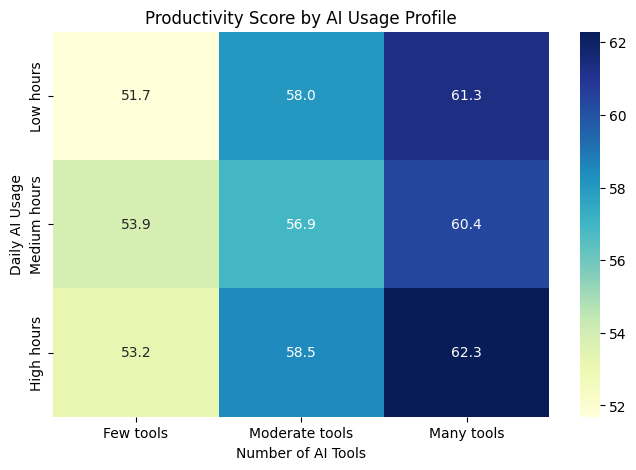

In [55]:
productivity_pivot = df.pivot_table(
    values="productivity_score",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    productivity_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Productivity Score by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

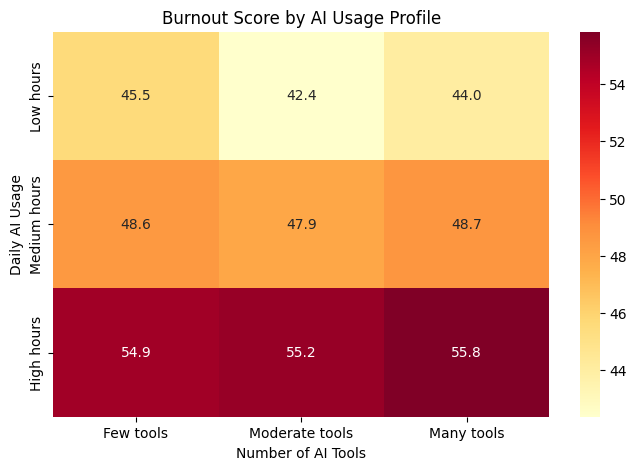

In [56]:
burnout_pivot = df.pivot_table(
    values="burnout_score",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    burnout_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Burnout Score by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

In [57]:
df["job_satisfaction_pct"] = (
    df["job_satisfaction_1_5"] / 5 * 100
)

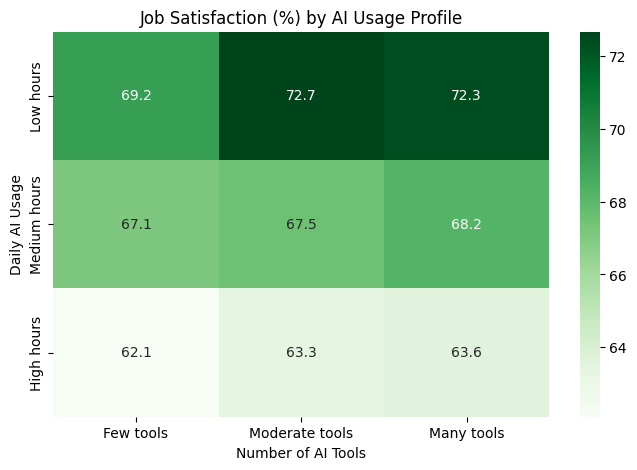

In [58]:
satisfaction_pivot = df.pivot_table(
    values="job_satisfaction_pct",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    satisfaction_pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.title("Job Satisfaction (%) by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

In [59]:
# Convert job satisfaction from 1-5 scale to percentage

df["job_satisfaction_pct"] = (
    df["job_satisfaction_1_5"] / 5 * 100
)

# Create an AI benefit index
# Higher productivity and satisfaction increase the score,
# higher burnout decreases it.

df["ai_benefit_index"] = (
    df["productivity_score"]
    + df["job_satisfaction_pct"]
    - df["burnout_score"]
)

# Compare benefit index across AI usage profiles

benefit_summary = (
    df.groupby(["hours_group", "tools_group"])[
        "ai_benefit_index"
    ]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

benefit_summary

hours_group   tools_group   
Low hours     Many tools        89.58
              Moderate tools    88.34
Medium hours  Many tools        79.91
              Moderate tools    76.54
Low hours     Few tools         75.31
Medium hours  Few tools         72.40
High hours    Many tools        70.05
              Moderate tools    66.66
              Few tools         60.38
Name: ai_benefit_index, dtype: float64

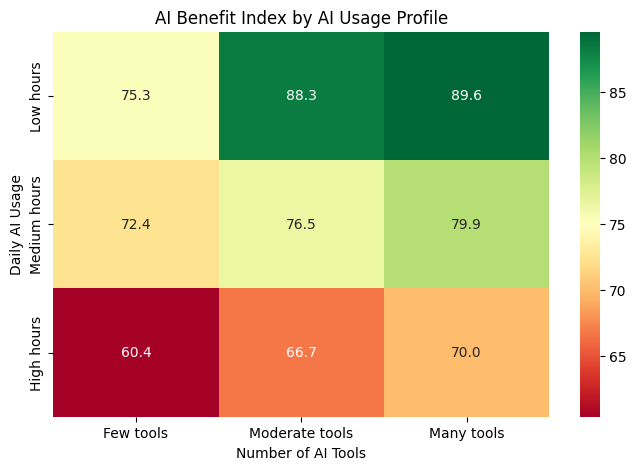

In [61]:
benefit_pivot = df.pivot_table(
    values="ai_benefit_index",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    benefit_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)

plt.title("AI Benefit Index by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

To evaluate the balance between productivity benefits and wellbeing costs, an AI Benefit Index was created.

The index combines:
- productivity score
- job satisfaction converted to a 0-100 scale
- burnout score as a negative component

Formula:

AI Benefit Index = Productivity Score + Job Satisfaction (%) - Burnout Score

Higher values indicate a more favorable balance between productivity, satisfaction and burnout.